In [7]:
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm

from cryosim.array_utils import radial_profile_2d
from cryosim.fft_tools import fft2

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Implementation 2

In [16]:
# --------------------------------------------------
# Generate one frame with coincidence loss
# --------------------------------------------------
def simulate_frame():
    n_pixels = det_size * det_size
    lam = dose_per_pixel * n_pixels

    # Poisson number of electrons
    n_e = torch.poisson(torch.tensor(lam)).int()

    # continuous detector coordinates
    coords = torch.rand((n_e, 2), device=device) * det_size

    # coincidence suppression
    keep = torch.ones(n_e, dtype=torch.bool, device=device)

    for i in range(n_e):
        if not keep[i]:
            continue

        d = torch.norm(coords[i + 1 :] - coords[i], dim=1)
        close = d < coinc_radius

        keep[i + 1 :][close] = False

    coords = coords[keep]

    # bin into pixels
    pixels = torch.zeros((det_size, det_size), device=device)

    ix = coords[:, 0].long().clamp(0, det_size - 1)
    iy = coords[:, 1].long().clamp(0, det_size - 1)

    pixels.index_put_(
        (ix, iy), torch.ones_like(ix, dtype=torch.float32), accumulate=True
    )

    return pixels

In [129]:
def simulate_frame_fast(
    det_size=512, dose_per_pixel=0.02, coinc_radius=1.5, device="cuda"
):
    n_pixels = det_size * det_size
    lam = dose_per_pixel * n_pixels

    # 1. Generate all coordinates at once
    n_e = torch.poisson(torch.tensor(lam, device=device)).int().item()
    coords = torch.rand((n_e, 2), device=device) * det_size

    # 2. Vectorized Coincidence Check
    # We compute the pairwise distance matrix: dists[i, j]
    # To save memory/time, we only care about j > i (upper triangle)
    if n_e > 1:
        # Compute squared distance to avoid expensive sqrt
        # (x1-x2)^2 + (y1-y2)^2 < r^2
        dist_sq = torch.cdist(coords, coords, p=2).pow(2)
        r_sq = coinc_radius**2

        # Create a mask for "too close" pairs
        # We only look at the upper triangle to avoid double-counting
        adj = (dist_sq < r_sq) & torch.triu(
            torch.ones((n_e, n_e), device=device, dtype=torch.bool), diagonal=1
        )

        # Greedy suppression: If an electron is "hit" by any previous electron, drop it
        # This approximates your loop logic without the Python overhead
        keep = torch.ones(n_e, dtype=torch.bool, device=device)

        # We still need to handle the "chain reaction" of suppression.
        # For low density, a simple approach is to find conflicts:
        conflicts = adj.any(dim=0)  # Any electron j that has an i < j too close

        # Note: True "Greedy" logic is hard to fully vectorize, but for 0.02 dose,
        # the probability of triple-overlaps is low enough that we can use
        # a slightly more aggressive parallel mask or a quick iterative pass.
        keep = ~conflicts
    else:
        keep = torch.ones(n_e, dtype=torch.bool, device=device)

    coords = coords[keep]

    # 3. Optimized Binning
    # Using 'scatter_add_' is generally faster than 'index_put_' for histogramming
    pixels = torch.zeros((det_size, det_size), device=device)
    ix = coords[:, 0].long().clamp(0, det_size - 1)
    iy = coords[:, 1].long().clamp(0, det_size - 1)

    # Flatten indices to use scatter_add
    flat_idx = ix * det_size + iy
    pixels.view(-1).scatter_add_(0, flat_idx, torch.ones_like(ix, dtype=torch.float32))

    return dist_sq, pixels


def compute_nps(images):
    # subtract mean (flat field condition)
    # images = images - images.mean(dim=(1,2), keepdim=True)

    # ps_list = []

    # for img in images:
    #     F = fft2(img, shift=True)
    #     ps = (F.abs()**2)
    #     ps_list.append(ps)

    # nps = torch.stack(ps_list).mean(0)

    # subtract mean (flat field condition)
    images = images.mean(0)
    images = images - images.mean()
    nps = torch.abs(fft2(images, shift=True)) ** 2

    return nps

100%|████████████████████████████████████████| 500/500 [00:00<00:00, 515.88it/s]


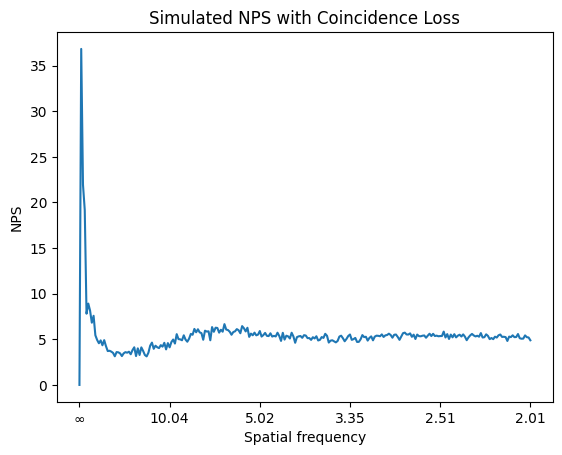

In [130]:
# --------------------------------------------------
# Parameters
# --------------------------------------------------
det_size = 512  # detector pixels
pixel_size = 1.0  # arbitrary units
dose_per_pixel = 0.02  # electrons/pixel/frame
coinc_radius = 5.0  # coincidence radius (pixels)
n_frames = 500

device = "cuda"

frames = []
for _ in tqdm(range(n_frames)):
    # frames.append(simulate_frame())
    dist_mat, frame = simulate_frame_fast(
        det_size=det_size,
        dose_per_pixel=dose_per_pixel,
        coinc_radius=coinc_radius,
        device="cuda",
    )
    frames.append(frame.detach().cpu())

frames = torch.stack(frames)
nps = compute_nps(frames)
radial_nps = radial_profile_2d(nps)

freq = torch.fft.fftfreq(det_size, pixel_size)
freq = freq[: det_size // 2]
plt.plot(freq, radial_nps[: det_size // 2])
plt.xlabel("Spatial frequency")

tick_freqs = torch.linspace(freq[0], freq[-1], 6)  # Start at index 1 to avoid 1/0
tick_labels = [f"{1 / f:.2f}" for f in tick_freqs]
tick_labels[0] = r"$\infty$"


plt.xticks(tick_freqs, tick_labels)

plt.ylabel("NPS")
plt.title("Simulated NPS with Coincidence Loss")
# plt.ylim([1e3, 1e4])
plt.show()

Text(0.5, 1.0, 'Distance matrix')

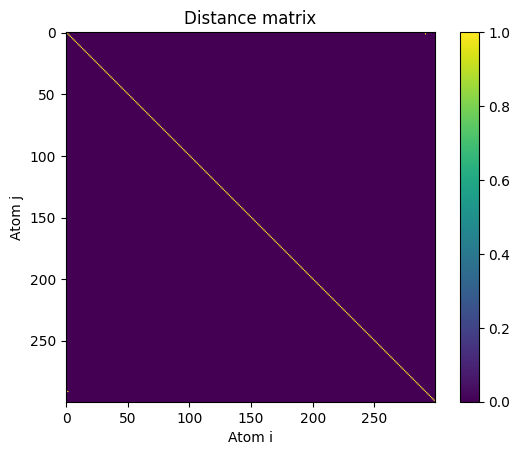

In [131]:
plt.imshow(dist_mat.cpu()[:300, :300] < 1.5**2)
plt.xlabel("Atom i")
plt.ylabel("Atom j")
plt.colorbar()
plt.title("Distance matrix")

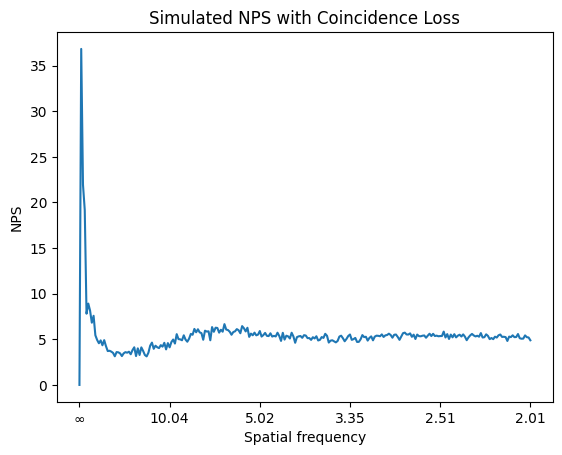

In [132]:
nps = compute_nps(frames)
radial_nps = radial_profile_2d(nps)

freq = torch.fft.fftfreq(det_size, pixel_size)
freq = freq[: det_size // 2]
plt.plot(freq, radial_nps[: det_size // 2])
plt.xlabel("Spatial frequency")

tick_freqs = torch.linspace(freq[0], freq[-1], 6)  # Start at index 1 to avoid 1/0
tick_labels = [f"{1 / f:.2f}" for f in tick_freqs]
tick_labels[0] = r"$\infty$"


plt.xticks(tick_freqs, tick_labels)

plt.ylabel("NPS")
plt.title("Simulated NPS with Coincidence Loss")
# plt.ylim([1e3, 1e5])
plt.show()

## Multiruns

In [135]:
# --------------------------------------------------
# Parameters & Setup
# --------------------------------------------------
det_size = 512
pixel_size = 1.0
# dose_per_pixel = 0.02
dose_per_pixel = [0.01, 0.02, 0.03, 0.04]
n_frames = 500
device = "cuda"

# The different radii you want to compare
radius = 1.5
# radii_to_test = [0.0, 1.5, 3.0, 5.0]
results = {}

# --------------------------------------------------
# Run Simulations
# --------------------------------------------------
# for r in radii_to_test:
#     print(f"Simulating coincidence radius: {r}")
for d in dose_per_pixel:
    print(f"Simulating dose_per_pixel: {d}")
    temp_frames = []

    for _ in tqdm(range(n_frames)):
        # Using the fast simulation function provided earlier
        dist_mat, frame = simulate_frame_fast(
            det_size=det_size,
            # dose_per_pixel=dose_per_pixel,
            dose_per_pixel=d,
            # coinc_radius=r,
            coinc_radius=radius,
            device=device,
        )
        temp_frames.append(frame.cpu())  # Move to CPU to save VRAM

    # Process NPS for this specific radius
    stacked = torch.stack(temp_frames)
    nps_2d = compute_nps(stacked)
    radial_nps = radial_profile_2d(nps_2d)

    # Store only the part up to Nyquist
    # results[r] = radial_nps[:det_size//2]
    results[d] = radial_nps[: det_size // 2]

Simulating dose_per_pixel: 0.01


100%|███████████████████████████████████████| 500/500 [00:00<00:00, 1492.76it/s]


Simulating dose_per_pixel: 0.02


100%|████████████████████████████████████████| 500/500 [00:00<00:00, 513.11it/s]


Simulating dose_per_pixel: 0.03


100%|████████████████████████████████████████| 500/500 [00:02<00:00, 222.39it/s]


Simulating dose_per_pixel: 0.04


100%|████████████████████████████████████████| 500/500 [00:03<00:00, 127.31it/s]


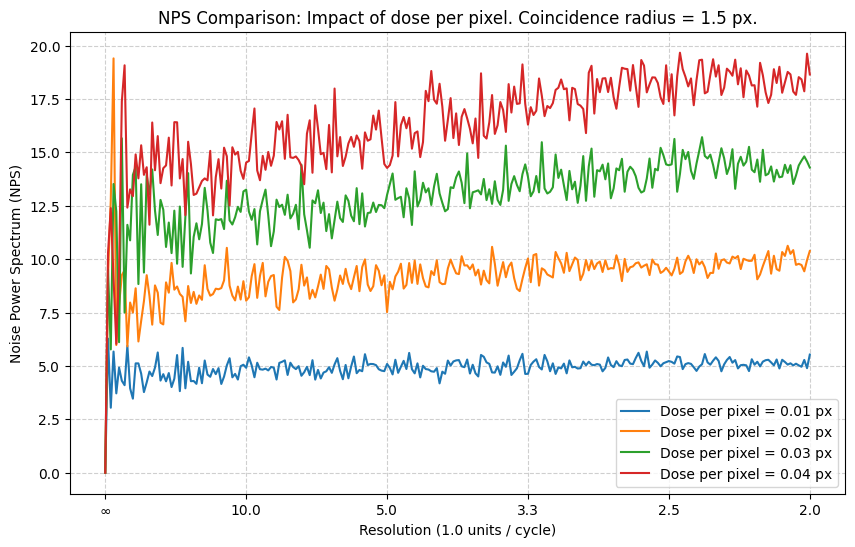

In [136]:
# --------------------------------------------------
# Plotting with Resolution Labels
# --------------------------------------------------
plt.figure(figsize=(10, 6))

# Define frequency axis once
freq = torch.fft.fftfreq(det_size, d=pixel_size)[: det_size // 2]

for d, data in results.items():
    plt.plot(freq.numpy(), data.numpy(), label=f"Dose per pixel = {d} px")
# for r, data in results.items():
#     plt.plot(freq.numpy(), data.numpy(), label=f"Coincidence radius = {r} px")

# Setup Ticks: Frequency to Resolution (1/f)
tick_freqs = torch.linspace(freq[0], freq[-1], 6)
tick_labels = []
for f in tick_freqs:
    if f == 0:
        tick_labels.append(r"$\infty$")
    else:
        # Resolution = 1/f. At Nyquist, this is 2 * pixel_size
        tick_labels.append(f"{1 / f:.1f}")

plt.xticks(tick_freqs.numpy(), tick_labels)

plt.xlabel(f"Resolution ({pixel_size} units / cycle)")
plt.ylabel("Noise Power Spectrum (NPS)")
# plt.ylim([1e2, 0.6e4])
# plt.ylim([2e2, 1e4])
# plt.title(f"NPS Comparison: Impact of coincidence radius. Dose per pixel = {dose_per_pixel}.")
plt.title("NPS Comparison: Impact of dose per pixel. Coincidence radius = 1.5 px.")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

## Adding coincidence loss to image.

In [104]:
micro = torch.load("micrograph_clean.pt")
micro.shape

torch.Size([1024, 1024])

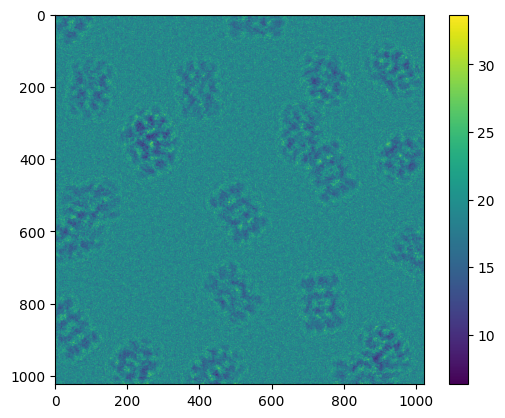

In [105]:
plt.imshow(micro)
plt.colorbar()

In [106]:
import torch


def apply_detector_physics(
    intensity_map,
    pixel_size_angstrom,
    dose_per_angstrom_sq_per_frame,
    coinc_radius_pixels=1.5,
    device="cuda",
):
    """
    Simulates a single frame of a Direct Electron Detector (DED).

    Args:
        intensity_map: 2D Tensor (normalized psi^2 from multislice).
        pixel_size_angstrom: Size of one pixel in Angstroms (e.g., 1.0).
        dose_per_angstrom_sq_per_frame: Physical dose (e/A^2).
        coinc_radius_pixels: Dead-time radius in pixels.
    """
    det_size = intensity_map.shape[0]

    # 1. Convert Physical Dose to Expected Electrons per Frame
    # Dose_per_pixel = Dose_per_A^2 * (A_per_pixel)^2
    dose_per_pixel = dose_per_angstrom_sq_per_frame * (pixel_size_angstrom**2)
    total_expected_electrons = dose_per_pixel * (det_size**2)

    # 2. Poisson Sampling (Particle Nature of Electrons)
    n_e = (
        torch.poisson(torch.tensor(total_expected_electrons, device=device))
        .int()
        .item()
    )
    if n_e < 2:
        return torch.zeros_like(intensity_map)

    # 3. Spatial Probability Sampling (Wave Nature -> Coordinates)
    # We treat intensity_map as the probability density
    prob_dist = intensity_map.view(-1) / intensity_map.sum()
    indices = torch.multinomial(prob_dist, num_samples=n_e, replacement=True)

    iy = (indices // det_size).float()
    ix = (indices % det_size).float()
    # Add random sub-pixel offset for continuous landing coordinates
    coords = torch.stack([ix, iy], dim=1) + torch.rand((n_e, 2), device=device)

    # 4. Grid-Based Coincidence Suppression (Memory Efficient)
    # Sort electrons by spatial grid cells to find neighbors fast
    grid_coords = (coords / coinc_radius_pixels).long()
    grid_w = int(det_size / coinc_radius_pixels) + 2
    grid_indices = grid_coords[:, 1] * grid_w + grid_coords[:, 0]

    sorted_idx = torch.argsort(grid_indices)
    coords = coords[sorted_idx]

    keep = torch.ones(n_e, dtype=torch.bool, device=device)
    window_size = 64  # Check 64 nearest neighbors in sorted list

    r_sq = coinc_radius_pixels**2
    for offset in range(1, window_size):
        if offset >= n_e:
            break
        d_sq = torch.sum((coords[:-offset] - coords[offset:]) ** 2, dim=1)
        too_close = d_sq < r_sq
        keep[offset:][too_close] = False

    # 5. Final Pixel Binning
    coords_final = coords[keep]
    pixels = torch.zeros((det_size, det_size), device=device)
    # To this (Standard Row-Major):
    iy_f = coords_final[:, 1].long().clamp(0, det_size - 1)  # Row index
    ix_f = coords_final[:, 0].long().clamp(0, det_size - 1)  # Col index
    flat_idx = iy_f * det_size + ix_f  # Row * Width + Col
    pixels.view(-1).scatter_add_(
        0, flat_idx, torch.ones_like(ix_f, dtype=torch.float32)
    )

    return pixels

In [136]:
# --- Setup ---
pixel_size = 1.0  # Angstroms per pixel
dose_per_angstrom = 20.0  # e-/A^2
dose_per_angstrom_per_frame = 1.0
n_frames = int(dose_per_angstrom / dose_per_angstrom_per_frame)

# --- Simulation ---
micrograph = torch.zeros_like(micro, device="cuda")

for _ in range(n_frames):
    frame = apply_detector_physics(
        (micro / micro.sum()).to("cuda"),
        pixel_size_angstrom=pixel_size,
        dose_per_angstrom_sq_per_frame=dose_per_angstrom_per_frame,
        coinc_radius_pixels=1.0,
    )
    micrograph += frame

# Final result in electron counts
micrograph_final = micrograph / n_frames

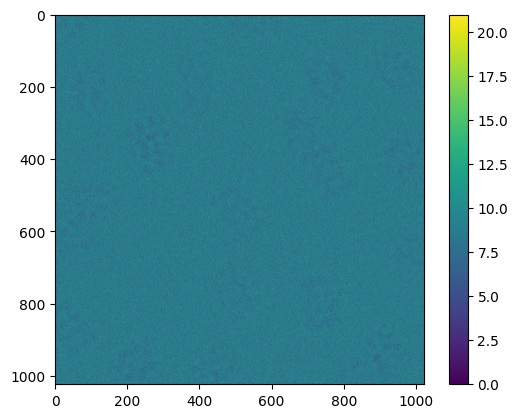

In [137]:
plt.imshow(micrograph.cpu())
plt.colorbar()

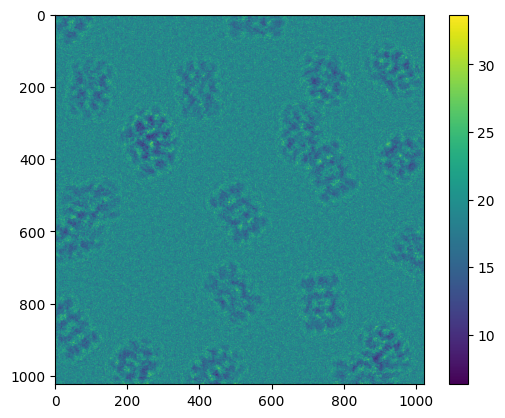

In [138]:
plt.imshow(micro.cpu())
plt.colorbar()

In [139]:
micro_poisson = torch.poisson(micro)

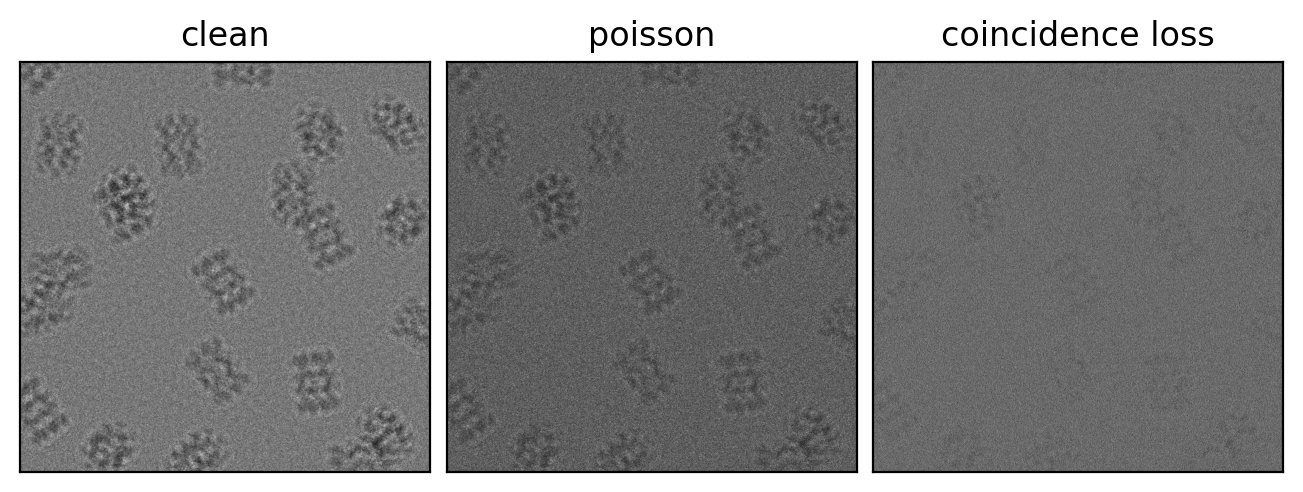

In [140]:
fig, axes = plt.subplots(1, 3, dpi=200, constrained_layout=True)
micros = [micro, micro_poisson, micrograph.cpu()]
titles = ["clean", "poisson", "coincidence loss"]
for i in range(3):
    ax = axes[i]
    ax.imshow(micros[i], cmap="grey")
    ax.set(xticks=[], yticks=[], title=titles[i])

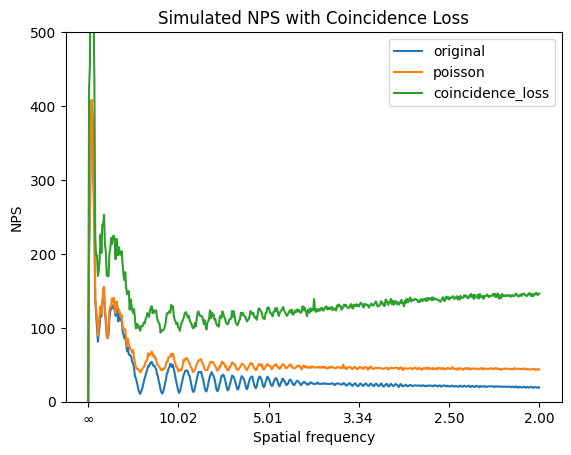

In [130]:
radial = radial_profile_2d(
    torch.abs(fft2(micrograph_final.cpu() - micrograph_final.cpu().mean(), shift=True))
)
radial_orig = radial_profile_2d(torch.abs(fft2(micro - micro.mean(), shift=True)))
radial_poisson = radial_profile_2d(
    torch.abs(fft2(micro_poisson - micro_poisson.mean(), shift=True))
)

freq = torch.fft.fftfreq(det_size, pixel_size)
freq = freq[: det_size // 2]
plt.plot(freq, radial_orig[: det_size // 2] / 1e2, label="original")
plt.plot(freq, radial_poisson[: det_size // 2] / 1e2, label="poisson")
plt.plot(freq, radial[: det_size // 2], label="coincidence_loss")
plt.xlabel("Spatial frequency")

tick_freqs = torch.linspace(freq[0], freq[-1], 6)  # Start at index 1 to avoid 1/0
tick_labels = [f"{1 / f:.2f}" for f in tick_freqs]
tick_labels[0] = r"$\infty$"


plt.xticks(tick_freqs, tick_labels)

plt.ylabel("NPS")
plt.title("Simulated NPS with Coincidence Loss")
plt.ylim([0, 0.5e3])
plt.legend()
plt.show()

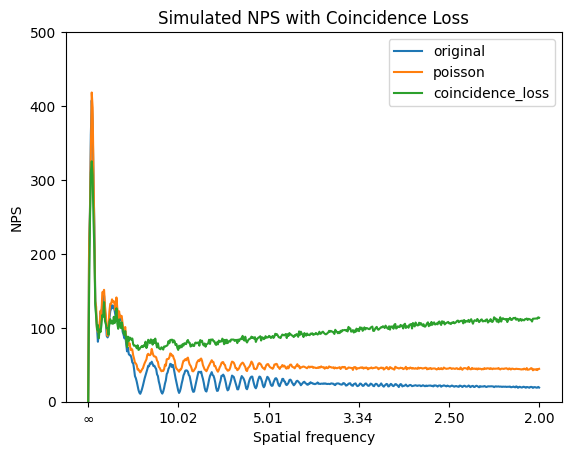

In [141]:
radial = radial_profile_2d(
    torch.abs(fft2(micrograph_final.cpu() - micrograph_final.cpu().mean(), shift=True))
)
radial_orig = radial_profile_2d(torch.abs(fft2(micro - micro.mean(), shift=True)))
radial_poisson = radial_profile_2d(
    torch.abs(fft2(micro_poisson - micro_poisson.mean(), shift=True))
)

freq = torch.fft.fftfreq(det_size, pixel_size)
freq = freq[: det_size // 2]
plt.plot(freq, radial_orig[: det_size // 2] / 1e2, label="original")
plt.plot(freq, radial_poisson[: det_size // 2] / 1e2, label="poisson")
plt.plot(freq, radial[: det_size // 2], label="coincidence_loss")
plt.xlabel("Spatial frequency")

tick_freqs = torch.linspace(freq[0], freq[-1], 6)  # Start at index 1 to avoid 1/0
tick_labels = [f"{1 / f:.2f}" for f in tick_freqs]
tick_labels[0] = r"$\infty$"


plt.xticks(tick_freqs, tick_labels)

plt.ylabel("NPS")
plt.title("Simulated NPS with Coincidence Loss")
plt.ylim([0, 0.5e3])
plt.legend()
plt.show()